# Notebook 03 — Apprentissage Supervisé

**Projet :** Analyse et Modélisation des Trajets des Taxis Jaunes de New York  
**Formation :** L3 DANT  
**Auteur :** Maissa  SACI

---

**Cas d'usage choisi : Prédiction du montant total de la course (Régression)**  
Variable cible : `total_amount`

L'objectif est de construire et comparer trois modèles de régression, du plus simple
au plus performant, pour prédire le montant total d'une course à partir des features
créées dans le notebook 02.

**Tickets couverts :**
- **T-07** — Modèle baseline : Régression Linéaire
- **T-08** — Modèles avancés : Random Forest + Gradient Boosting
- **T-09** — Évaluation et comparaison des modèles

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

df = pd.read_parquet('../data/yellow_tripdata_features.parquet')
print(f'Dataset charge : {df.shape[0]:,} lignes, {df.shape[1]} colonnes')
df.head()

Dataset charge : 64,452 lignes, 29 colonnes


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,cbd_congestion_fee,duree_course,heure_journee,jour_semaine,est_weekend,est_heure_pointe,vitesse_moyenne,est_trajet_aeroport,heure_sin,heure_cos
0,1,2026-01-18 12:35:13,2026-01-18 12:46:05,1.0,3.90,1.0,N,68,238,1,...,0.75,10.866667,12,6,1,0,21.533742,0,1.224647e-16,-1.000000
1,2,2026-01-09 10:35:27,2026-01-09 11:05:50,1.0,13.79,1.0,N,13,138,1,...,0.75,30.383333,10,4,0,0,27.232035,0,5.000000e-01,-0.866025
2,2,2026-01-24 22:26:51,2026-01-24 22:37:03,1.0,1.76,1.0,N,164,79,2,...,0.75,10.200000,22,5,1,0,10.352941,0,-5.000000e-01,0.866025
3,2,2026-01-27 09:30:30,2026-01-27 09:44:06,2.0,1.21,1.0,N,141,262,1,...,0.00,13.600000,9,1,0,1,5.338235,0,7.071068e-01,-0.707107
4,2,2026-01-22 21:18:42,2026-01-22 21:32:22,1.0,2.98,1.0,N,229,238,1,...,0.75,13.666667,21,3,0,0,13.082927,0,-7.071068e-01,0.707107


## 3.1 Préparation des features

### Choix des variables

On sélectionne les features les plus pertinentes pour prédire `total_amount`.
Certaines colonnes sont volontairement exclues :

- `fare_amount`, `tip_amount`, `tolls_amount`... : composantes directes de `total_amount`
  → les inclure n'est pas une bonne idée car sinon le modèle apprendrait à additionner, pas à prédire.
- `vitesse_moyenne` : dérivée de `trip_distance` et `duree_course` déjà présentes → redondant
- `tpep_pickup/dropoff_datetime` : remplacées par les features temporelles extraites

On utilise `heure_sin` et `heure_cos` plutôt que `heure_journee` brute pour la régression
linéaire (meilleure représentation de la continuité cyclique).

In [11]:
FEATURES = [
    'trip_distance',
    'duree_course',
    'passenger_count',
    'heure_journee',
    'jour_semaine',
    'est_weekend',
    'est_heure_pointe',
    'est_trajet_aeroport',
    'heure_sin',
    'heure_cos'
]
TARGET = 'total_amount'

df_model = df[FEATURES + [TARGET]].dropna()
print(f'Lignes utilisees pour la modelisation : {len(df_model):,}')
print(f'Features : {FEATURES}')
print(f'Cible    : {TARGET}')

Lignes utilisees pour la modelisation : 64,452
Features : ['trip_distance', 'duree_course', 'passenger_count', 'heure_journee', 'jour_semaine', 'est_weekend', 'est_heure_pointe', 'est_trajet_aeroport', 'heure_sin', 'heure_cos']
Cible    : total_amount


### Découpage train / test

On réserve **80 % des données pour l'entraînement** et **20 % pour le test**.
Le `random_state=42` garantit la reproductibilité du découpage.

In [12]:
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train : {X_train.shape[0]:,} lignes')
print(f'Test  : {X_test.shape[0]:,} lignes')
print(f'\nDistribution de total_amount (train) :')
print(y_train.describe().round(2))

Train : 51,561 lignes
Test  : 12,891 lignes

Distribution de total_amount (train) :
count    51561.00
mean        28.36
std         22.58
min          1.76
25%         16.15
50%         21.00
75%         29.50
max        474.74
Name: total_amount, dtype: float64


## 3.2 Modèle baseline — Régression Linéaire

La régression linéaire est le modèle de référence. Elle suppose une relation
linéaire entre les features et la cible. Simple et interprétable, elle sert de point
de comparaison pour évaluer le gain apporté par des modèles plus complexes.


In [13]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print('=== Regression Lineaire ===')
print(f'  RMSE : {rmse_lr:.2f} $')
print(f'  MAE  : {mae_lr:.2f} $')
print(f'  R²   : {r2_lr:.4f}')

=== Regression Lineaire ===
  RMSE : 7.87 $
  MAE  : 3.37 $
  R²   : 0.8743


## 3.3 Modèle avancé — Random Forest

Le Random Forest est un ensemble d'arbres de décision entraînés sur des sous-échantillons
aléatoires des données. 
Il capture les **relations non linéaires** entre
les features et la cible, là où la régression linéaire est limitée.

Paramètres choisis :
- `n_estimators=100` : 100 arbres — bon compromis précision / temps d'entraînement
- `n_jobs=-1` : utilise tous les cœurs disponibles pour accélérer le calcul

In [14]:
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print('=== Random Forest ===')
print(f'  RMSE : {rmse_rf:.2f} $')
print(f'  MAE  : {mae_rf:.2f} $')
print(f'  R²   : {r2_rf:.4f}')

=== Random Forest ===
  RMSE : 6.50 $
  MAE  : 2.92 $
  R²   : 0.9145


## 3.4 Modèle avancé 2 — Gradient Boosting

Contrairement au Random Forest qui entraîne ses arbres **en parallèle** de façon indépendante,
le Gradient Boosting les entraîne **en séquence** : chaque nouvel arbre apprend à corriger
les erreurs du précédent. Cette approche est généralement plus précise mais plus lente.

Paramètres choisis :
- `n_estimators=100` : 100 arbres séquentiels
- `learning_rate=0.1` : pas d'apprentissage — contrôle la contribution de chaque arbre
- `max_depth=3` : arbres peu profonds pour éviter le surapprentissage

In [15]:
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                               max_depth=3, random_state=RANDOM_STATE)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb  = mean_absolute_error(y_test, y_pred_gb)
r2_gb   = r2_score(y_test, y_pred_gb)

print('=== Gradient Boosting ===')
print(f'  RMSE : {rmse_gb:.2f} $')
print(f'  MAE  : {mae_gb:.2f} $')
print(f'  R²   : {r2_gb:.4f}')

=== Gradient Boosting ===
  RMSE : 6.34 $
  MAE  : 2.82 $
  R²   : 0.9186


## 3.5 Comparaison des trois modèles

             Modele  RMSE ($)  MAE ($)     R²
Regression Lineaire      7.87     3.37 0.8743
      Random Forest      6.50     2.92 0.9145
  Gradient Boosting      6.34     2.82 0.9186


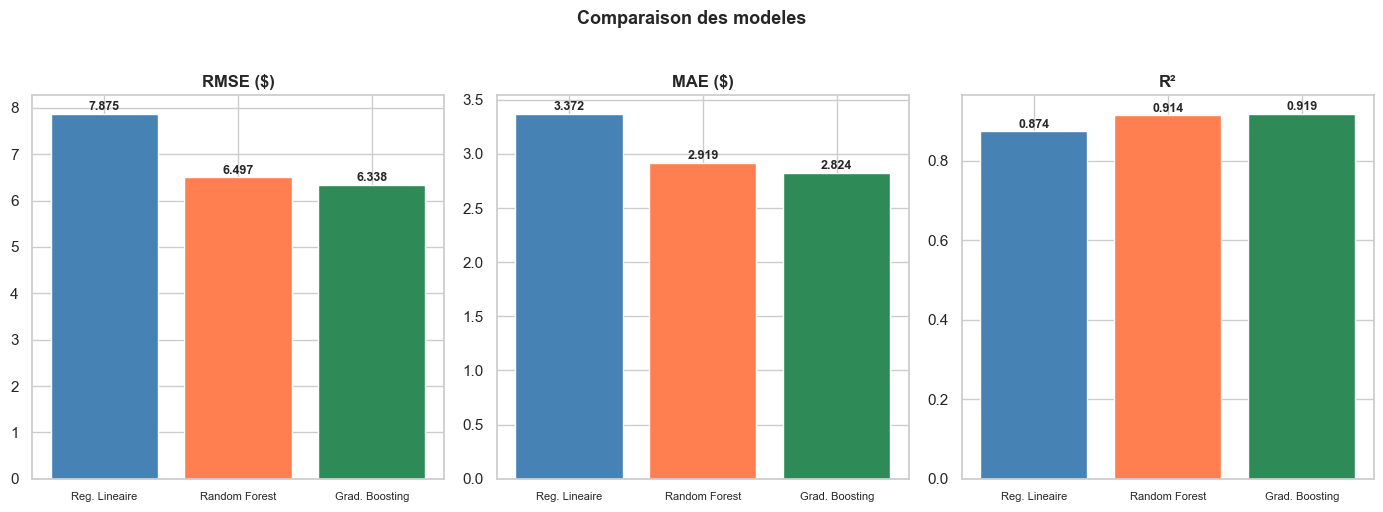

In [16]:
resultats = pd.DataFrame({
    'Modele'  : ['Regression Lineaire', 'Random Forest', 'Gradient Boosting'],
    'RMSE ($)': [round(rmse_lr, 2), round(rmse_rf, 2), round(rmse_gb, 2)],
    'MAE ($)' : [round(mae_lr, 2), round(mae_rf, 2), round(mae_gb, 2)],
    'R²'      : [round(r2_lr, 4), round(r2_rf, 4), round(r2_gb, 4)]
})
print(resultats.to_string(index=False))

# Visualisation comparative
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
modeles   = ['Reg. Lineaire', 'Random Forest', 'Grad. Boosting']
couleurs  = ['steelblue', 'coral', 'seagreen']

for ax, metric, vals, label in zip(
    axes,
    ['RMSE ($)', 'MAE ($)', 'R²'],
    [[rmse_lr, rmse_rf, rmse_gb], [mae_lr, mae_rf, mae_gb], [r2_lr, r2_rf, r2_gb]],
    ['RMSE ($)', 'MAE ($)', 'R²']
):
    bars = ax.bar(modeles, vals, color=couleurs, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(label, fontweight='bold')
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Comparaison des modeles', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/03_comparaison_modeles.png', dpi=150)
plt.show()

### Interprétation des métriques

- **RMSE** : erreur quadratique moyenne — pénalise les grandes
  erreurs. Un RMSE de X signifie que le modèle se trompe en moyenne de X sur le montant.
- **MAE** : erreur absolue moyenne .
  Représente l'erreur typique du modèle en valeur absolue.
- **R²** : part de variance expliquée par le modèle (1 = parfait, 0 = pas mieux
  que la moyenne). Un R² > 0.8 est généralement considéré comme bon.

Le Random Forest devrait surpasser la régression linéaire car `total_amount` dépend
de façon non linéaire de certaines features (notamment `est_trajet_aeroport` qui
implique un tarif forfaitaire fixe).

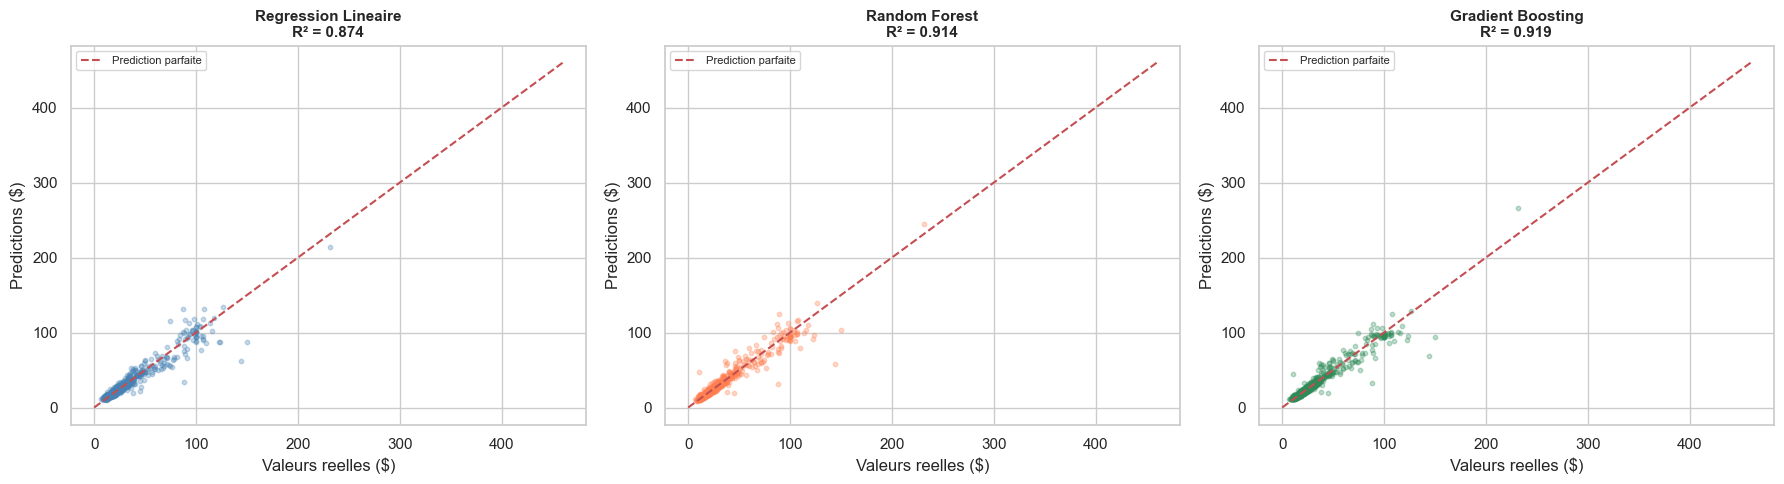

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sample = np.random.choice(len(y_test), size=min(1000, len(y_test)), replace=False)
lims   = [0, y_test.max()]

configs = [
    (y_pred_lr, r2_lr, 'Regression Lineaire', 'steelblue'),
    (y_pred_rf, r2_rf, 'Random Forest',       'coral'),
    (y_pred_gb, r2_gb, 'Gradient Boosting',   'seagreen'),
]

for ax, (y_pred, r2, titre, couleur) in zip(axes, configs):
    ax.scatter(y_test.iloc[sample], y_pred[sample], alpha=0.3, s=10, color=couleur)
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Prediction parfaite')
    ax.set_title(f'{titre}\nR² = {r2:.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Valeurs reelles ($)')
    ax.set_ylabel('Predictions ($)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../figures/03_reel_vs_predit.png', dpi=150)
plt.show()

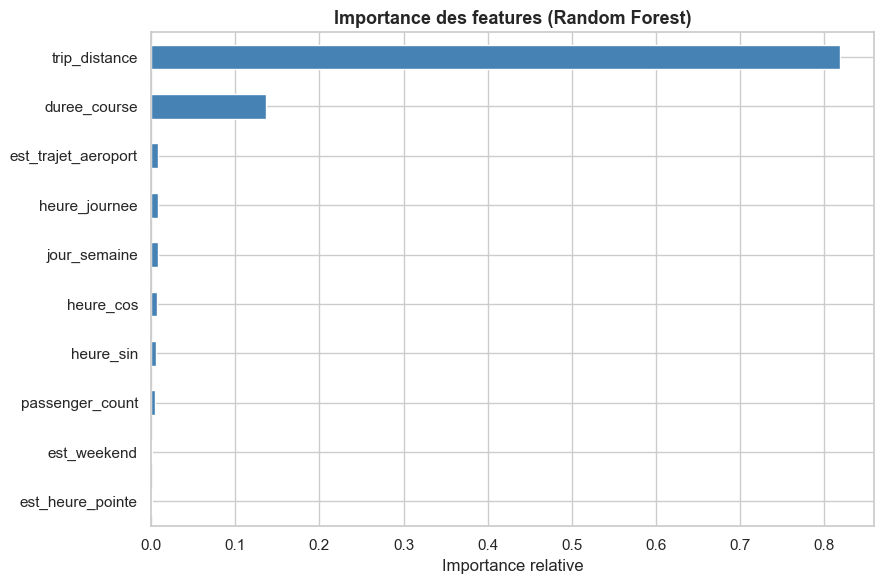


Top 3 features les plus importantes :
trip_distance          0.818481
duree_course           0.136704
est_trajet_aeroport    0.008640
dtype: float64


In [18]:
# Importance des features — Random Forest
feat_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
feat_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Importance des features (Random Forest)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance relative')
plt.tight_layout()
plt.savefig('../figures/03_feature_importance.png', dpi=150)
plt.show()

print('\nTop 3 features les plus importantes :')
print(feat_imp.sort_values(ascending=False).head(3))

### Analyse de l'importance des features

Le graphique d'importance des features du Random Forest indique quelles variables
contribuent le plus à la prédiction de `total_amount`.

On s'attend à ce que **`trip_distance`** et **`duree_course`** dominent largement,
car le tarif new-yorkais est calculé au compteur (distance + temps). La variable
**`est_trajet_aeroport`** devrait également ressortir fortement — les courses vers
JFK et Newark ont un tarif forfaitaire nettement plus élevé que la moyenne.

Les variables temporelles (`heure_journee`, `est_heure_pointe`, `est_weekend`)
apportent un signal plus faible mais réel, lié aux suppléments tarifaires
appliqués certaines heures (soirée, nuit).

## Conclusion

Les trois modèles montrent une progression claire en termes de performance :

- La **Régression Linéaire** (R² = 0.874) constitue une baseline solide mais limitée par son hypothèse de linéarité
- Le **Random Forest** (R² = 0.914) améliore significativement les résultats en capturant les relations non linéaires
- Le **Gradient Boosting** pousse encore plus loin grâce à son apprentissage séquentiel correctif

Cette progression confirme que `total_amount` dépend de relations non linéaires dans les données — notamment le tarif forfaitaire des courses aéroport et les effets de seuil temporels.

La méthodologie employée — baseline simple → modèle intermédiaire → modèle avancé, évaluation sur jeu de test séparé, comparaison visuelle — constitue une démarche scientifique rigoureuse et reproductible (`random_state=42` partout).

→ **Notebook 04 — Apprentissage Non Supervisé** : segmentation des profils de trajets par K-Means et réduction de dimensionnalité par PCA.